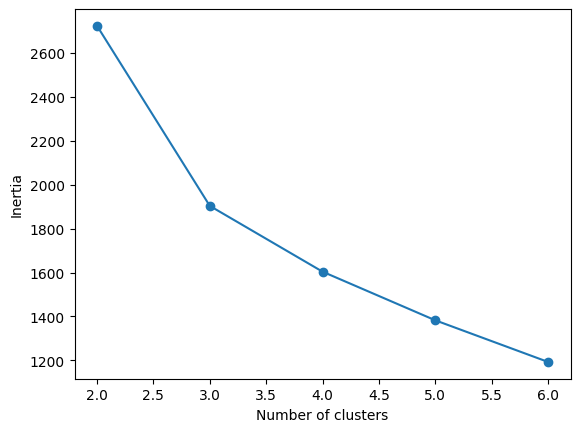

         monthly_income  savings_ratio  discretionary_pct  essential_pct
cluster                                                                 
0           1212.943350      -2.794791           0.059490       0.915076
1            704.500000      -5.497453           0.060477       0.913969
2           1029.121302      -2.894636           0.089019       0.877761


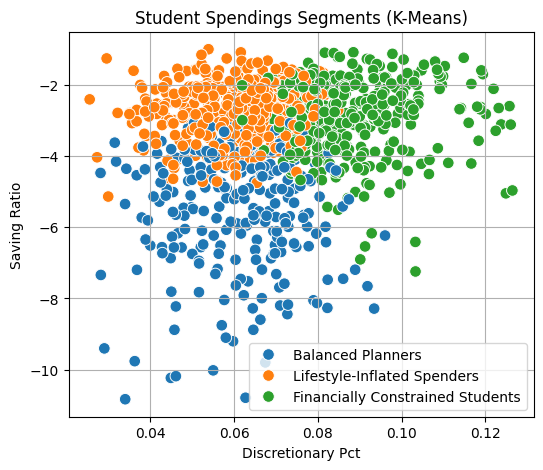

Coefficient: 18.22250904232448
Intercept: -4.790958375511588


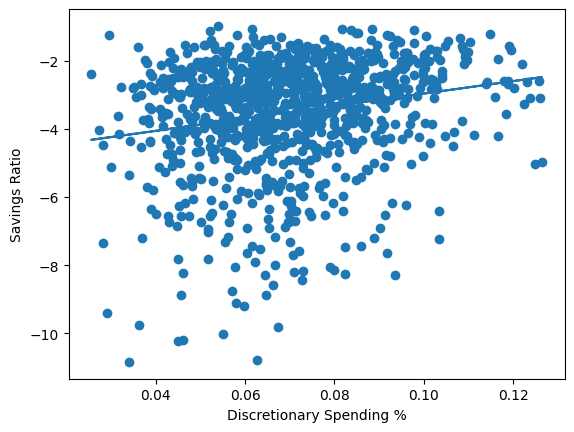

         monthly_income  savings_ratio  discretionary_pct  essential_pct
cluster                                                                 
0           1212.943350      -2.794791           0.059490       0.915076
1            704.500000      -5.497453           0.060477       0.913969
2           1029.121302      -2.894636           0.089019       0.877761
You belong to: Financially Constrained Students


c:\Users\Bhavya Lakhani\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, roc_auc_score, recall_score, f1_score
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import pickle

df = pd.read_csv("student_spending.csv")
# print(df)
# print(df.info()) # no nulls
# print(df.describe())


expense_cols = [
    'tuition','housing','food','transportation','books_supplies',
    'entertainment','personal_care','technology','health_wellness','miscellaneous'
]

df['total_expense'] = df[expense_cols].sum(axis=1)
df['net_savings'] = df['monthly_income'] + df['financial_aid'] - df['total_expense']
df['savings_ratio'] = df['net_savings'] / (df['monthly_income'] + df['financial_aid'] + 1e-6)
df['essential_expense'] = (
    df['tuition'] + df['housing'] + df['food'] +
    df['transportation'] + df['health_wellness']
)
df['discretionary_expense'] = (
    df['entertainment'] + df['personal_care'] +
    df['technology'] + df['miscellaneous']
)
df['essential_pct'] = df['essential_expense'] / (df['total_expense'] + 1e-6)
df['discretionary_pct'] = df['discretionary_expense'] / (df['total_expense'] + 1e-6)

features = [
    'monthly_income',
    'savings_ratio',
    'discretionary_pct',
    'essential_pct'
]

scaler = StandardScaler()
X = df[features]
X_scaled = scaler.fit_transform(X)

# print(np.mean(X_scaled, axis=0))
# print(np.std(X_scaled, axis=0))

# KMeans Clustering 

inertia = []
K = range(2, 7)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Elbow
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = df.groupby('cluster')[features].mean()
print(cluster_summary)

cluster_names = {
    0: "Lifestyle-Inflated Spenders",
    1: "Balanced Planners",
    2: "Financially Constrained Students"
}
df['cluster_name'] = df['cluster'].map(cluster_names)

# KMeans Scatter --
# monthly_income vs savings_ratio
# df.groupby('cluster')[['savings_ratio', 'discretionary_pct']].mean().plot(kind='bar')

plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="discretionary_pct", y="savings_ratio", hue="cluster_name", s=70)
plt.xlabel("Discretionary Pct")
plt.ylabel("Saving Ratio")
plt.title("Student Spendings Segments (K-Means)")
plt.legend()
plt.grid(True)
plt.show()


# Linear Regression

X_reg = df[['discretionary_pct']]
y_reg = df['savings_ratio']

model = LinearRegression()
model.fit(X_reg, y_reg)

coef = model.coef_[0]
intercept = model.intercept_

print("Coefficient:", coef)
print("Intercept:", intercept)

# Linear Reg Graph
plt.scatter(X_reg, y_reg)
plt.plot(X_reg, model.predict(X_reg))
plt.xlabel("Discretionary Spending %")
plt.ylabel("Savings Ratio")
plt.show()

cluster_financial_view = df.groupby('cluster')[
    ['monthly_income', 'savings_ratio', 'discretionary_pct', 'essential_pct']
].mean()

print(cluster_financial_view)


# User Input
def classify_user(monthly_income, essential_spend, discretionary_spend):
    
    total_expense = essential_spend + discretionary_spend
    savings_ratio = (monthly_income - total_expense) / (monthly_income + 1e-6)
    discretionary_pct = discretionary_spend / (monthly_income + 1e-6)
    essential_pct = essential_spend / (monthly_income + 1e-6)
    
    user_features = [[
        monthly_income,
        savings_ratio,
        discretionary_pct,
        essential_pct
    ]]
    
    user_scaled = scaler.transform(user_features)
    cluster_id = kmeans.predict(user_scaled)[0]
    
    return cluster_id


cluster_id = classify_user(1200, 900, 150)
persona = cluster_names[cluster_id]

print("You belong to:", persona)

pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(kmeans, open("kmeans.pkl", "wb"))

Coefficient (slope)
If negative:
As discretionary spending increases, savings decrease

If positive:
Higher discretionary spending is associated with higher savings (unlikely here)


| Cluster | Summary                               |
| ------- | ------------------------------------- |
| 0       | Higher income, still negative savings |
| 1       | Higher discretionary spending         |
| 2       | Lowest income, worst savings          |
